In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/bit_sathy_carbon_daily_3yr.csv")

In [3]:
df.head()

,date,day_of_week,is_weekend,month,day_of_year,academic_phase,is_holiday,avg_temp_c,max_temp_c,rainfall_mm,...,hostellers_present,day_scholars_present,electricity_kwh,diesel_l,water_l,waste_kg,lpg_kg,solar_kwh_generated,carbon_kg,carbon_kg_next_day
0,2023-01-01,6,1,1,1,winter_break,1,22.9,29.3,0.0,...,680,82,5539.0,13.9,98883.7,255.8,14.23,840.8,4219.0,4239.3
1,2023-01-02,0,0,1,2,winter_break,0,23.7,30.3,0.0,...,680,82,5583.0,2.7,103667.1,246.1,15.38,811.6,4239.3,4508.5
2,2023-01-03,1,0,1,3,winter_break,0,23.0,29.4,0.0,...,680,82,6054.5,0.0,120568.9,239.0,13.98,884.5,4508.5,8811.3
3,2023-01-04,2,0,1,4,even_sem_classes,0,24.6,32.0,0.0,...,3298,3854,9446.3,0.0,596178.1,1799.9,87.10,818.9,8811.3,9819.5
4,2023-01-05,3,0,1,5,even_sem_classes,0,23.5,29.0,0.0,...,3298,3854,10087.4,0.0,621113.4,1812.2,86.38,964.7,9819.5,9841.5


In [4]:
df['academic_phase'].value_counts()

academic_phase
even_sem_classes    394
odd_sem_classes     333
summer_break        183
even_sem_exam        78
odd_sem_exam         63
winter_break         44
Name: count, dtype: int64

In [5]:
df['academic_phase'].replace("even_sem_classes" , 0 , inplace=True)
df['academic_phase'].replace("odd_sem_classes" , 1 , inplace=True)
df['academic_phase'].replace("summer_break" , 2 , inplace=True)
df['academic_phase'].replace("even_sem_exam" , 3 , inplace=True)
df['academic_phase'].replace("odd_sem_exam" , 4 , inplace=True)
df['academic_phase'].replace("winter_break" , 5 , inplace=True)

C:\Users\SELVAGANAPATHI\AppData\Local\Temp\ipykernel_37832\2632367569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['academic_phase'].replace("even_sem_classes" , 0 , inplace=True)
C:\Users\SELVAGANAPATHI\AppData\Local\Temp\ipykernel_37832\2632367569.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [6]:
df.head()

,date,day_of_week,is_weekend,month,day_of_year,academic_phase,is_holiday,avg_temp_c,max_temp_c,rainfall_mm,...,hostellers_present,day_scholars_present,electricity_kwh,diesel_l,water_l,waste_kg,lpg_kg,solar_kwh_generated,carbon_kg,carbon_kg_next_day
0,2023-01-01,6,1,1,1,5,1,22.9,29.3,0.0,...,680,82,5539.0,13.9,98883.7,255.8,14.23,840.8,4219.0,4239.3
1,2023-01-02,0,0,1,2,5,0,23.7,30.3,0.0,...,680,82,5583.0,2.7,103667.1,246.1,15.38,811.6,4239.3,4508.5
2,2023-01-03,1,0,1,3,5,0,23.0,29.4,0.0,...,680,82,6054.5,0.0,120568.9,239.0,13.98,884.5,4508.5,8811.3
3,2023-01-04,2,0,1,4,0,0,24.6,32.0,0.0,...,3298,3854,9446.3,0.0,596178.1,1799.9,87.10,818.9,8811.3,9819.5
4,2023-01-05,3,0,1,5,0,0,23.5,29.0,0.0,...,3298,3854,10087.4,0.0,621113.4,1812.2,86.38,964.7,9819.5,9841.5


In [7]:
df.drop("occupancy_total" , axis = 1 , inplace=True)

In [8]:
df['academic_phase'].value_counts()

academic_phase
0    394
1    333
2    183
3     78
4     63
5     44
Name: count, dtype: int64

In [9]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
df = df.sort_values("date").reset_index(drop=True)

In [11]:
#splitting data time wise as trin and test (as it is time series data)
train_df = df[df["date"].dt.year <= 2024]
test_df = df[df["date"].dt.year == 2025]

In [12]:
print(train_df["date"].min())
print(train_df["date"].max())

print(test_df["date"].min())
print(test_df["date"].max())

2023-01-01 00:00:00
2024-12-31 00:00:00
2025-01-01 00:00:00
2025-12-30 00:00:00


In [13]:
#Splitting input and output data
xTrain = train_df.drop(
    columns=[
        "date",
        "day_of_year",
        "carbon_kg_next_day"
    ]
)

yTrain = train_df["carbon_kg_next_day"]


xTest = test_df.drop(
    columns=[
        "date",
        "day_of_year",
        "carbon_kg_next_day"
    ]
)

yTest = test_df["carbon_kg_next_day"]

In [14]:
#import models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

#import evaluation features
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [15]:
rf_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

xgb_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

dt_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [16]:
models = [
    ("RandomForest" , RandomForestRegressor() , rf_grid),
    ("XGBoost" , XGBRegressor() , xgb_grid),
    ("DecisionTree" , DecisionTreeRegressor() , dt_grid)
]

In [17]:
from sklearn.model_selection import GridSearchCV
results = []

In [18]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

Training RandomForest model...
Best Parameters : {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
MAE  : 303.72
MSE  : 330539.34
RMSE : 574.93
R²   : 0.9270


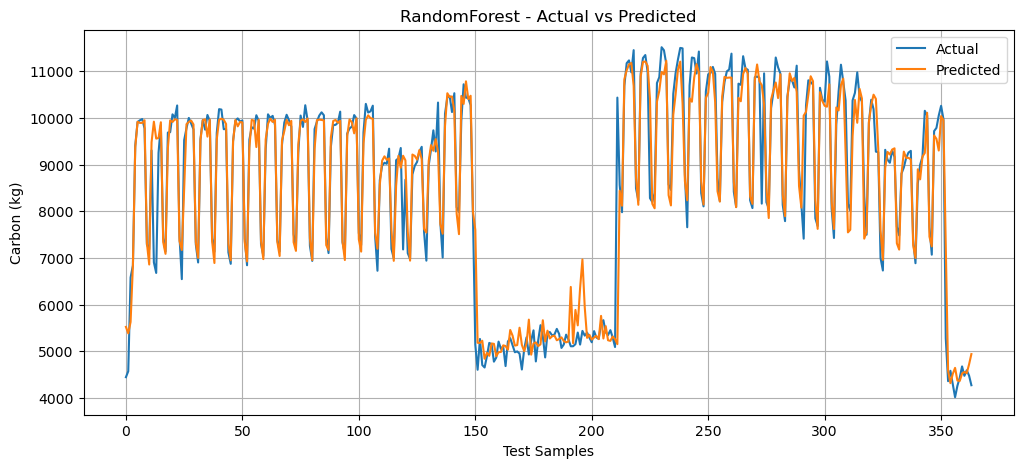

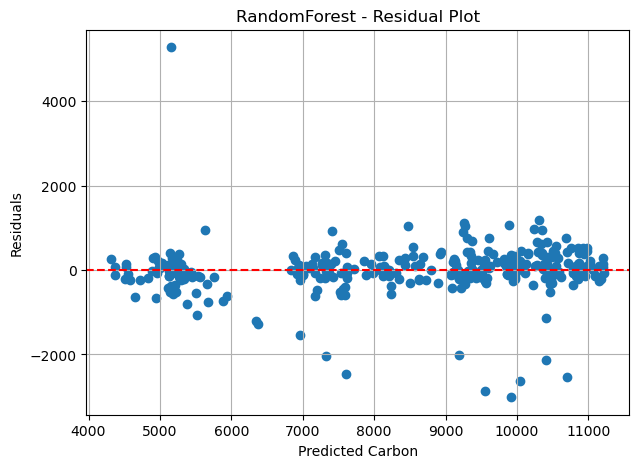


Top 10 Important Features

                 Feature  Importance
14               water_l    0.273669
0            day_of_week    0.228377
18             carbon_kg    0.186594
15              waste_kg    0.079582
11  day_scholars_present    0.065600
16                lpg_kg    0.042879
12       electricity_kwh    0.036753
10    hostellers_present    0.026218
5             avg_temp_c    0.020373
6             max_temp_c    0.015130


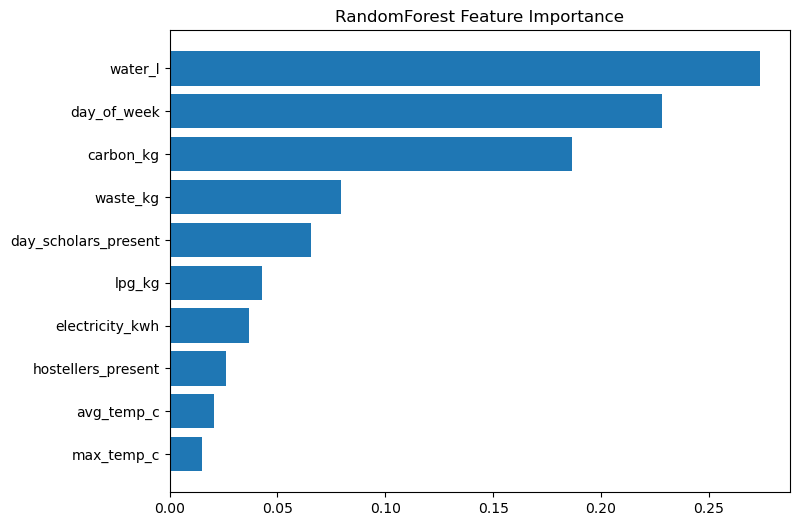

Training XGBoost model...
Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0}
MAE  : 309.77
MSE  : 312959.40
RMSE : 559.43
R²   : 0.9309


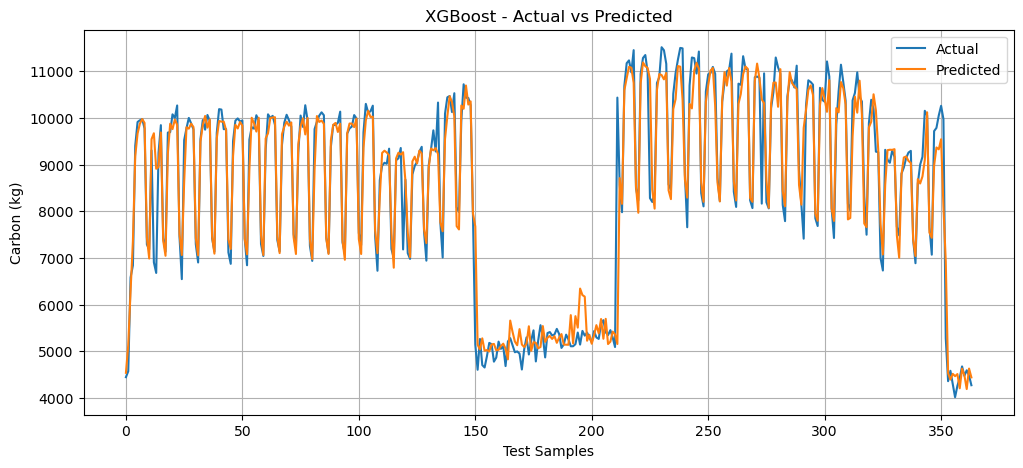

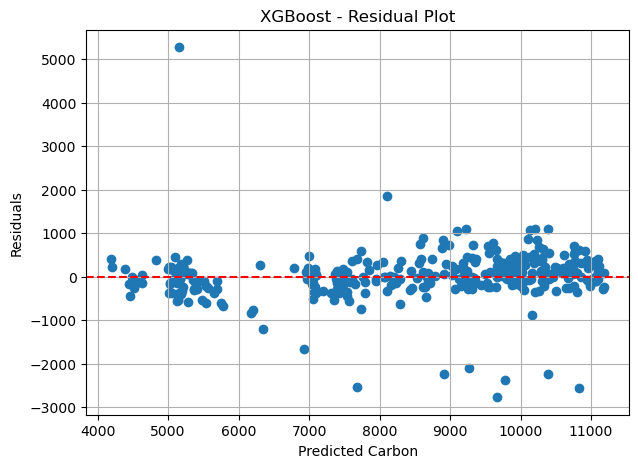


Top 10 Important Features

                 Feature  Importance
11  day_scholars_present    0.491432
10    hostellers_present    0.444307
0            day_of_week    0.021114
12       electricity_kwh    0.016721
18             carbon_kg    0.004501
14               water_l    0.003510
3         academic_phase    0.003462
5             avg_temp_c    0.002717
6             max_temp_c    0.002239
15              waste_kg    0.001904


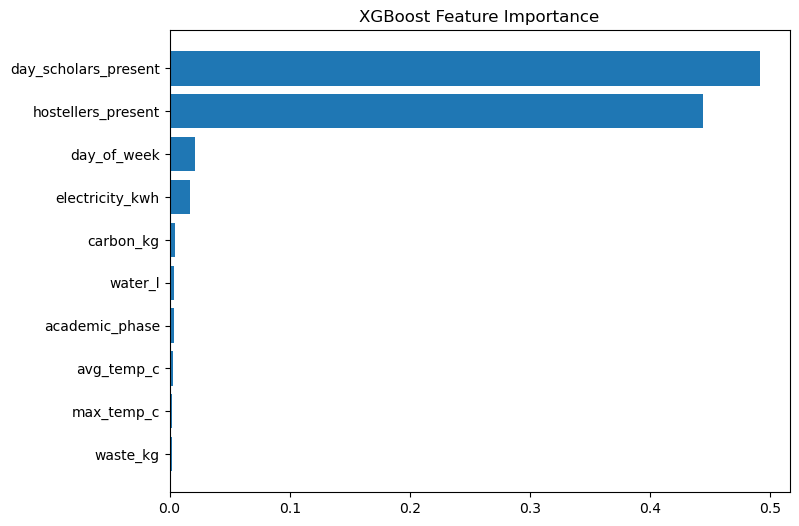

Training DecisionTree model...
Best Parameters : {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
MAE  : 341.44
MSE  : 434357.64
RMSE : 659.06
R²   : 0.9041


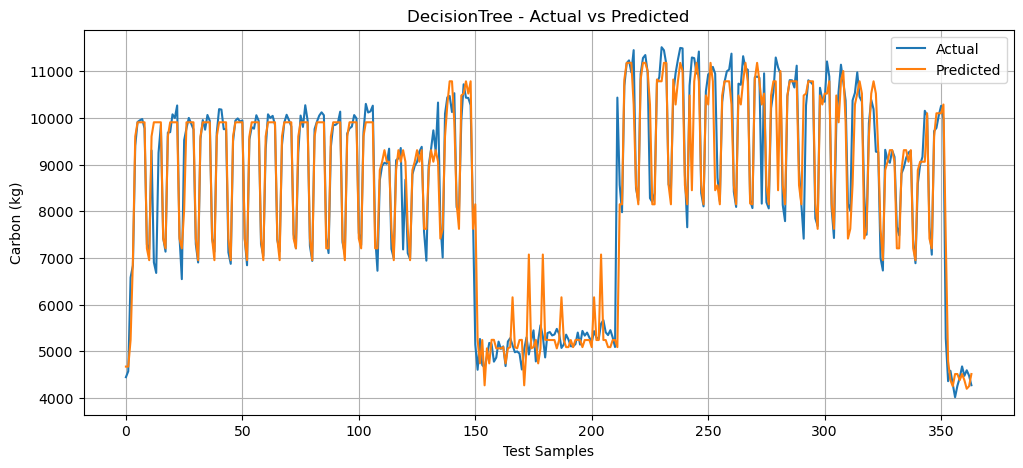

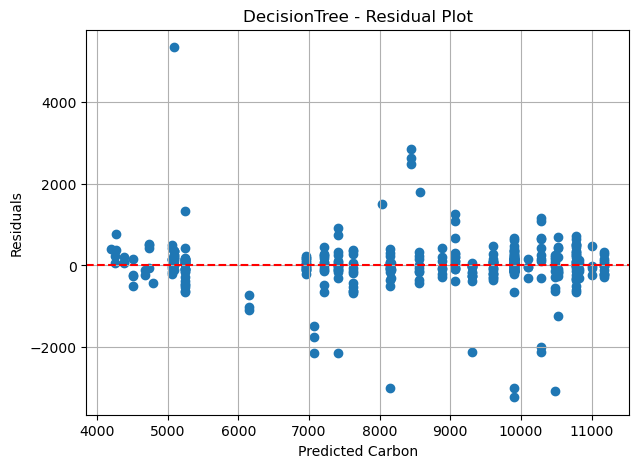


Top 10 Important Features

                Feature  Importance
16               lpg_kg    0.662723
0           day_of_week    0.232322
12      electricity_kwh    0.038404
6            max_temp_c    0.025525
5            avg_temp_c    0.009648
2                 month    0.007093
3        academic_phase    0.006609
18            carbon_kg    0.005231
17  solar_kwh_generated    0.005153
15             waste_kg    0.004444


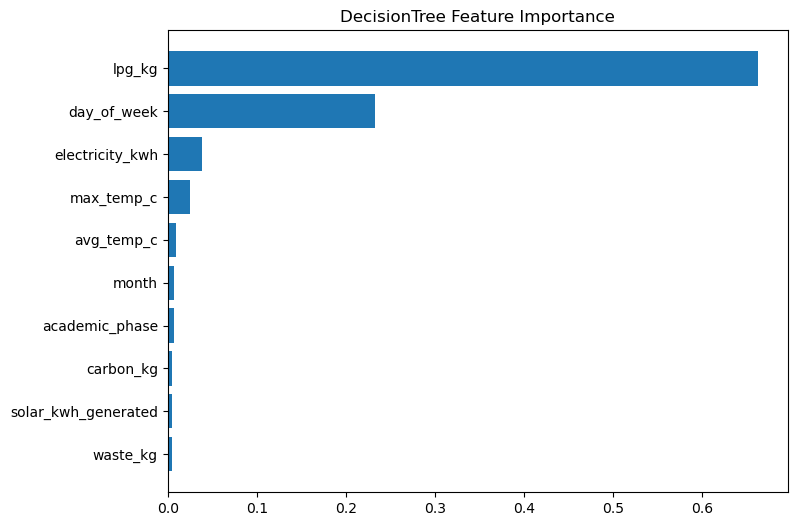


Training Completed!

Final Results

          Model         MAE            MSE        RMSE        R2  \
1       XGBoost  309.773775  312959.398018  559.427742  0.930895   
0  RandomForest  303.722272  330539.336714  574.925505  0.927013   
2  DecisionTree  341.436490  434357.642839  659.058148  0.904089   

                                     Best Parameters  
1  {'colsample_bytree': 0.8, 'learning_rate': 0.0...  
0  {'max_depth': 8, 'min_samples_leaf': 1, 'min_s...  
2  {'max_depth': 6, 'min_samples_leaf': 2, 'min_s...  


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

results = []

for name, model, parameters in models:

    print(f"Training {name} model...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=parameters,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(xTrain, yTrain)

    bestModel = grid.best_estimator_

    # Prediction
    yPred = bestModel.predict(xTest)

    # Metrics
    mae = mean_absolute_error(yTest, yPred)
    mse = mean_squared_error(yTest, yPred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yTest, yPred)

    # Save best model
    joblib.dump(bestModel, f"{name}_best_model.pkl")

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Best Parameters": grid.best_params_
    })

    # Console Output
    print("Best Parameters :", grid.best_params_)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    # Actual vs Predicted Plot
    plt.figure(figsize=(12,5))

    plt.plot(yTest.values, label="Actual")
    plt.plot(yPred, label="Predicted")

    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Test Samples")
    plt.ylabel("Carbon (kg)")
    plt.legend()
    plt.grid(True)

    plt.show()
    # Residual Plot

    residuals = yTest - yPred

    plt.figure(figsize=(7,5))

    plt.scatter(yPred, residuals)

    plt.axhline(
        y=0,
        color="red",
        linestyle="--"
    )

    plt.title(f"{name} - Residual Plot")
    plt.xlabel("Predicted Carbon")
    plt.ylabel("Residuals")
    plt.grid(True)

    plt.show()

    # Feature Importance

    if hasattr(bestModel, "feature_importances_"):

        importance = pd.DataFrame({
            "Feature": xTrain.columns,
            "Importance": bestModel.feature_importances_
        })

        importance = importance.sort_values(
            by="Importance",
            ascending=False
        )

        print("\nTop 10 Important Features\n")
        print(importance.head(10))

        plt.figure(figsize=(8,6))

        plt.barh(
            importance["Feature"][:10],
            importance["Importance"][:10]
        )

        plt.gca().invert_yaxis()

        plt.title(f"{name} Feature Importance")

        plt.show()

print("\nTraining Completed!")

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print("\nFinal Results\n")
print(results_df)

In [22]:
import joblib
best_model = bestModel
joblib.dump(best_model, "carbon_prediction_model.pkl")

['carbon_prediction_model.pkl']

In [24]:
sample_input = {
    "day_of_week": 2,                 # Wednesday
    "is_weekend": 0,
    "month": 7,
    "academic_phase": 1,              # Regular Semester
    "is_holiday": 0,
    "avg_temp_c": 34.8,
    "max_temp_c": 39.2,
    "rainfall_mm": 2.5,
    "cloud_cover": 42,
    "power_cut_hours": 0.0,
    "occupancy_total": 8650,
    "hostellers_present": 3200,
    "day_scholars_present": 5450,
    "electricity_kwh": 18750,
    "diesel_l": 18.6,
    "water_l": 612000,
    "waste_kg": 1580,
    "lpg_kg": 185,
    "solar_kwh_generated": 4380,
    "carbon_kg": 12485
}

In [26]:
import pandas as pd

sample_df = pd.DataFrame([sample_input])

prediction = best_model.predict(sample_df)

print(f"Predicted Tomorrow CO₂ : {prediction[0]:.2f} kg")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- occupancy_total
